### Animal Faces Classification Task: Understanding Underfitting, Overfitting, Regularization, Dropout and Hyperparameter Tuning and reviweing validation

In [1]:
# Import necessary libraries
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf
from keras.src.legacy.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from keras.regularizers import l1, l2
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping
import kagglehub

# Set random seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

In [2]:
# Download the dataset
path = kagglehub.dataset_download("andrewmvd/animal-faces")
print("Path to dataset files:", path)

# Define paths (assuming standard structure: afhq/train and afhq/val with subfolders cat, dog, wild)
data_dir = os.path.join(path, 'afhq')
train_dir = os.path.join(data_dir, 'train')
test_dir = os.path.join(data_dir, 'val')  # This is the test set in this task

num_classes = 3  # cat, dog, wild

# This is new way to load data(you can even set batch size by it if you want!):
train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(150, 150),
    class_mode='categorical',
    shuffle=False
)

# Note: The 'val' folder is used as the test set here. If you need a validation set, split the data from the train set.

Path to dataset files: C:\Users\mhkaz\.cache\kagglehub\datasets\andrewmvd\animal-faces\versions\1
Found 11706 images belonging to 3 classes.
Found 2924 images belonging to 3 classes.
Found 1500 images belonging to 3 classes.


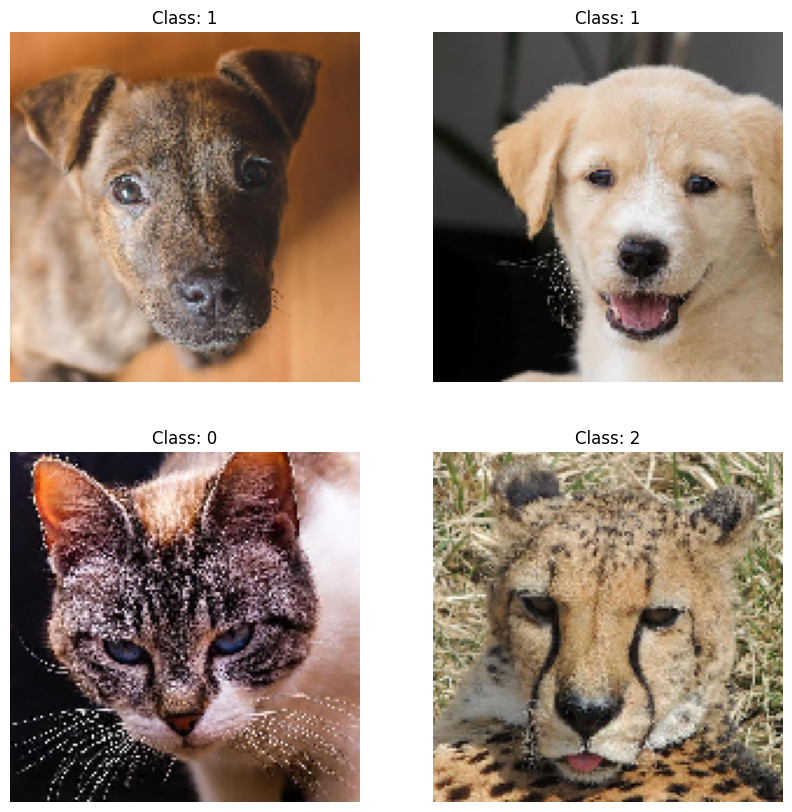

In [3]:
# Optional: Visualize a batch of images to confirm loading
import matplotlib.pyplot as plt

images, labels = next(train_generator)  # Get one batch
plt.figure(figsize=(10, 10))
for i in range(4):  # Show first 4 images
    plt.subplot(2, 2, i+1)
    plt.imshow(images[i])
    plt.title(f'Class: {labels[i].argmax()}')
    plt.axis('off')
plt.show()

In [4]:
# Function to plot training history (accuracy and loss curves)
def plot_history(history, title):
    plt.figure(figsize=(12, 4))
    
    # Plot accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    if 'val_accuracy' in history.history:
        plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title(f'{title} - Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    
    # Plot loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    if 'val_loss' in history.history:
        plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'{title} - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.show()

# Function to evaluate on test set
def evaluate_model(model):
    test_loss, test_acc = model.evaluate(test_generator)
    print(f'Test Accuracy: {test_acc:.4f}')
    return test_acc

c:\Users\mhkaz\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 100, 100, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 100, 100, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 100, 100, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 100, 100, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 50, 50, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 50, 50, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 50, 50, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 50, 50, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 25, 25, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 25, 25, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 25, 25, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 25, 25, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     9,437,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 9,730,083 (37.12 MB)

 Trainable params: 9,728,163 (37.11 MB)

 Non-trainable params: 1,920 (7.50 KB)

c:\Users\mhkaz\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
366/366 ━━━━━━━━━━━━━━━━━━━━ 151s 406ms/step - accuracy: 0.8315 - loss: 0.4605 - val_accuracy: 0.6406 - val_loss: 0.9257
Epoch 2/50
366/366 ━━━━━━━━━━━━━━━━━━━━ 143s 391ms/step - accuracy: 0.9100 - loss: 0.2464 - val_accuracy: 0.8820 - val_loss: 0.3573
Epoch 3/50
366/366 ━━━━━━━━━━━━━━━━━━━━ 152s 416ms/step - accuracy: 0.9405 - loss: 0.1640 - val_accuracy: 0.9217 - val_loss: 0.2467
Epoch 4/50
366/366 ━━━━━━━━━━━━━━━━━━━━ 150s 410ms/step - accuracy: 0.9535 - loss: 0.1264 - val_accuracy: 0.9347 - val_loss: 0.1929
Epoch 5/50
366/366 ━━━━━━━━━━━━━━━━━━━━ 142s 389ms/step - accuracy: 0.9593 - loss: 0.1076 - val_accuracy: 0.9309 - val_loss: 0.1941
Epoch 6/50
366/366 ━━━━━━━━━━━━━━━━━━━━ 141s 385ms/step - accuracy: 0.9692 - loss: 0.0807 - val_accuracy: 0.9422 - val_loss: 0.1704
Epoch 7/50
366/366 ━━━━━━━━━━━━━━━━━━━━ 138s 377ms/step - accuracy: 0.9760 - loss: 0.0658 - val_accuracy: 0.9313 - val_loss: 0.1979
Epoch 8/50
366/366 ━━━━━━━━━━━━━━━━━━━━ 136s 371ms/step - accuracy: 0.9780 -

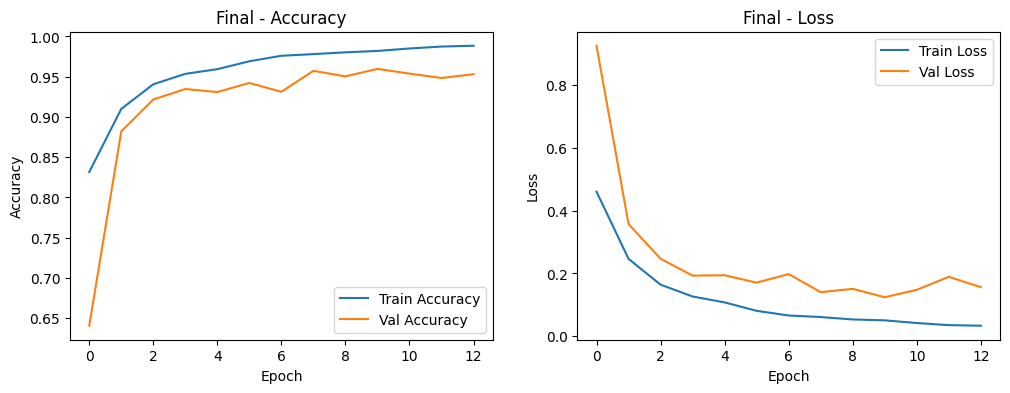

47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 90ms/step - accuracy: 0.9700 - loss: 0.0896
Test Accuracy: 0.9700


0.9700000286102295

In [ ]:
#model 0
model = Sequential([
    Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(100, 100, 3)),
    BatchNormalization(),
    Conv2D(32, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.20),

    Conv2D(64, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(64, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.20),

    Conv2D(128, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(128, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.20),

    Flatten(),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.25),
    Dense(3, activation='softmax')
])

model.summary()

model.compile(optimizer=Adam(learning_rate=0.0001),
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])

early_stopping = EarlyStopping(
    monitor='val_loss', 
    patience=3,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    train_generator,
    epochs=50,
    validation_data=validation_generator,
    callbacks=[early_stopping]
)

plot_history(history,"Final")

evaluate_model(model)

c:\Users\mhkaz\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     5,308,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,403,587 (20.61 MB)

 Trainable params: 5,402,883 (20.61 MB)

 Non-trainable params: 704 (2.75 KB)

c:\Users\mhkaz\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
366/366 ━━━━━━━━━━━━━━━━━━━━ 142s 381ms/step - accuracy: 0.8767 - loss: 0.3432 - val_accuracy: 0.7548 - val_loss: 0.8772
Epoch 2/50
366/366 ━━━━━━━━━━━━━━━━━━━━ 135s 370ms/step - accuracy: 0.9585 - loss: 0.1176 - val_accuracy: 0.9487 - val_loss: 0.1671
Epoch 3/50
366/366 ━━━━━━━━━━━━━━━━━━━━ 129s 353ms/step - accuracy: 0.9741 - loss: 0.0780 - val_accuracy: 0.9511 - val_loss: 0.1346
Epoch 4/50
366/366 ━━━━━━━━━━━━━━━━━━━━ 129s 354ms/step - accuracy: 0.9712 - loss: 0.0815 - val_accuracy: 0.9436 - val_loss: 0.1593
Epoch 5/50
366/366 ━━━━━━━━━━━━━━━━━━━━ 132s 361ms/step - accuracy: 0.9855 - loss: 0.0445 - val_accuracy: 0.7671 - val_loss: 0.9059
Epoch 6/50
366/366 ━━━━━━━━━━━━━━━━━━━━ 128s 351ms/step - accuracy: 0.9736 - loss: 0.0746 - val_accuracy: 0.9542 - val_loss: 0.1123
Epoch 7/50
366/366 ━━━━━━━━━━━━━━━━━━━━ 126s 344ms/step - accuracy: 0.9888 - loss: 0.0348 - val_accuracy: 0.9525 - val_loss: 0.1392
Epoch 8/50
366/366 ━━━━━━━━━━━━━━━━━━━━ 127s 348ms/step - accuracy: 0.9888 -

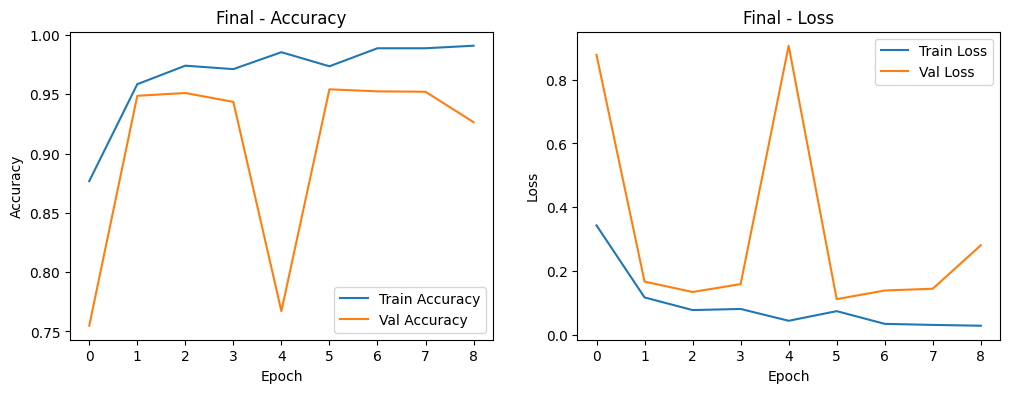

47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 88ms/step - accuracy: 0.9673 - loss: 0.0932
Test Accuracy: 0.9673


0.9673333168029785

In [ ]:
#Model 1
model = Sequential([
    Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(150, 150, 3)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(64, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(128, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(3, activation='softmax')
])

model.summary()

model.compile(optimizer=Adam(learning_rate=0.0005),
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])

early_stopping = EarlyStopping(
    monitor='val_loss', 
    patience=3,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    train_generator,
    epochs=50,
    validation_data=validation_generator,
    callbacks=[early_stopping]
)

plot_history(history,"Final")

evaluate_model(model)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 75, 75, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 75, 75, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 75, 75, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 75, 75, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 37, 37, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 37, 37, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 37, 37, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 37, 37, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 37, 37, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 37, 37, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 18, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 18, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 18, 18, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 18, 18, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 18, 18, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 18, 18, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 9, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 9, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 10368)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │     5,308,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 5,601,315 (21.37 MB)

 Trainable params: 5,599,395 (21.36 MB)

 Non-trainable params: 1,920 (7.50 KB)

Epoch 1/50
366/366 ━━━━━━━━━━━━━━━━━━━━ 84s 223ms/step - accuracy: 0.8515 - loss: 1.3375 - val_accuracy: 0.7459 - val_loss: 1.2905
Epoch 2/50
366/366 ━━━━━━━━━━━━━━━━━━━━ 76s 207ms/step - accuracy: 0.9395 - loss: 0.7084 - val_accuracy: 0.9244 - val_loss: 0.6002
Epoch 3/50
366/366 ━━━━━━━━━━━━━━━━━━━━ 78s 212ms/step - accuracy: 0.9585 - loss: 0.4485 - val_accuracy: 0.9292 - val_loss: 0.4858
Epoch 4/50
366/366 ━━━━━━━━━━━━━━━━━━━━ 80s 217ms/step - accuracy: 0.9584 - loss: 0.3873 - val_accuracy: 0.9405 - val_loss: 0.8091
Epoch 5/50
366/366 ━━━━━━━━━━━━━━━━━━━━ 81s 222ms/step - accuracy: 0.9701 - loss: 0.3221 - val_accuracy: 0.9610 - val_loss: 0.3198
Epoch 6/50
366/366 ━━━━━━━━━━━━━━━━━━━━ 77s 210ms/step - accuracy: 0.9726 - loss: 0.3073 - val_accuracy: 0.9497 - val_loss: 0.3892
Epoch 7/50
366/366 ━━━━━━━━━━━━━━━━━━━━ 76s 207ms/step - accuracy: 0.9718 - loss: 0.3514 - val_accuracy: 0.9456 - val_loss: 0.5259
Epoch 8/50
366/366 ━━━━━━━━━━━━━━━━━━━━ 79s 215ms/step - accuracy: 0.9709 - loss: 0

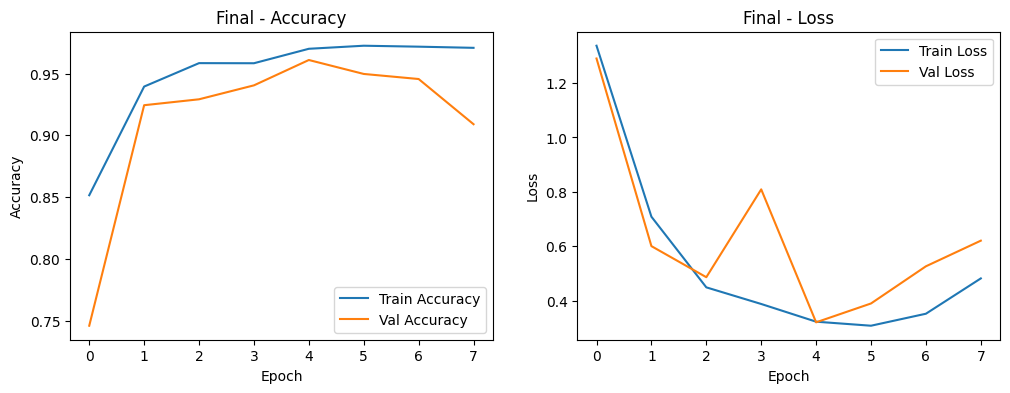

47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step - accuracy: 0.9573 - loss: 0.3172
Test Accuracy: 0.9573


0.9573333263397217

In [ ]:
#model 2
model = Sequential([
    Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(75, 75, 3)),
    BatchNormalization(),
    Conv2D(32, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),

    Conv2D(64, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(64, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),

    Conv2D(128, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(128, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),

    Flatten(),
    Dense(512, activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.5),
    Dense(3, activation='softmax')
])

model.summary()

model.compile(optimizer="adam",
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])

early_stopping = EarlyStopping(
    monitor='val_loss', 
    patience=3,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    train_generator,
    epochs=50,
    validation_data=validation_generator,
    callbacks=[early_stopping]
)

plot_history(history,"Final")

evaluate_model(model)

c:\Users\mhkaz\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 248, 248, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 124, 124, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 122, 122, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 61, 61, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 59, 59, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 29, 29, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 107648)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    55,116,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,211,075 (210.61 MB)

 Trainable params: 55,211,075 (210.61 MB)

 Non-trainable params: 0 (0.00 B)

c:\Users\mhkaz\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
366/366 ━━━━━━━━━━━━━━━━━━━━ 235s 639ms/step - accuracy: 0.8502 - loss: 0.3918 - val_accuracy: 0.9224 - val_loss: 0.2029
Epoch 2/50
366/366 ━━━━━━━━━━━━━━━━━━━━ 231s 632ms/step - accuracy: 0.9659 - loss: 0.1032 - val_accuracy: 0.9446 - val_loss: 0.1525
Epoch 3/50
366/366 ━━━━━━━━━━━━━━━━━━━━ 235s 641ms/step - accuracy: 0.9805 - loss: 0.0560 - val_accuracy: 0.9425 - val_loss: 0.1624
Epoch 4/50
366/366 ━━━━━━━━━━━━━━━━━━━━ 233s 636ms/step - accuracy: 0.9887 - loss: 0.0314 - val_accuracy: 0.9405 - val_loss: 0.1824
Epoch 5/50
366/366 ━━━━━━━━━━━━━━━━━━━━ 240s 655ms/step - accuracy: 0.9927 - loss: 0.0226 - val_accuracy: 0.9456 - val_loss: 0.1903
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.


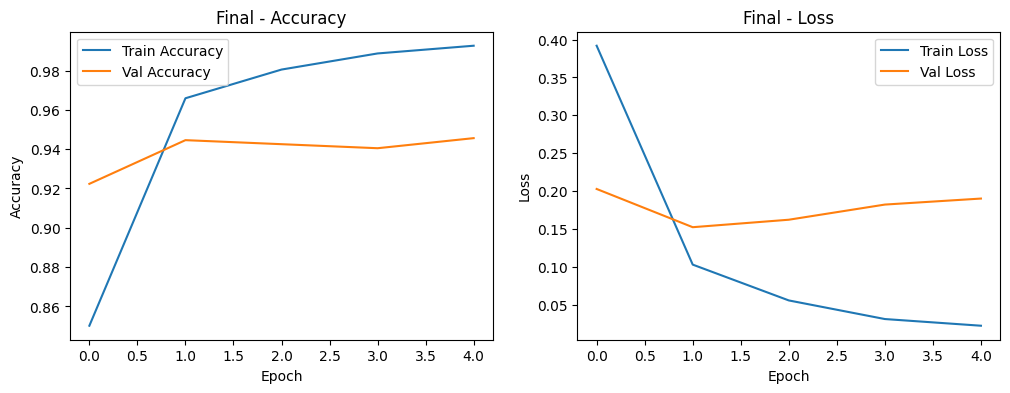

47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 122ms/step - accuracy: 0.9553 - loss: 0.1354
Test Accuracy: 0.9553


0.9553333520889282

In [ ]:
#model 3
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(250, 250, 3)),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Flatten(),

    Dense(512, activation='relu'),
    Dropout(0.3),

    Dense(3, activation='softmax')
])

model.summary()

model.compile(optimizer=Adam(learning_rate=0.0005),
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])

early_stopping = EarlyStopping(
    monitor='val_loss', 
    patience=3,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    train_generator,
    epochs=50,
    validation_data=validation_generator,
    callbacks=[early_stopping]
)

plot_history(history,"Final")

evaluate_model(model)